# Bootcamp Final Quiz

**Time Limit:** 60 minutes  
**Total Points:** 100  
**Format:** Open Internet — you may use Google, Stack Overflow, documentation, etc.  

---

### Rules
1. All code cells **must run without errors** when submitted
2. Write your markdown/text answers in the designated cells
3. Do **not** modify the Setup cell below
4. Questions build on each other — complete them in order
5. Read each question carefully before answering

### Grading Breakdown
| Section | Topic | Points |
|---------|-------|--------|
| 1 | Concepts & Warm-Up | 15 |
| 2 | Linear Regression & Metrics | 15 |
| 3 | Logistic Regression & Classification | 25 |
| 4 | Tree-Based Models | 25 |
| 5 | Model Pipeline & Deployment | 10 |
| 6 | Boss Level — End-to-End Challenge | 10 |
| **Total** | | **100** |

**Good luck!**

In [3]:
print("Hello, World!")

Hello, World!


In [4]:
# ============================================================
# SETUP CELL — DO NOT MODIFY
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    mean_squared_error,
    r2_score,
    precision_recall_curve,
    auc,
)
from sklearn.datasets import make_classification
import joblib

# Load datasets
heart_df = pd.read_csv("data/heart.csv")
social_df = pd.read_csv("data/Social_Network_Ads.csv")

print(f"heart_df: {heart_df.shape[0]} rows, {heart_df.shape[1]} columns")
print(f"social_df: {social_df.shape[0]} rows, {social_df.shape[1]} columns")
print("\n✅ Setup complete — you're ready to go!")

heart_df: 303 rows, 14 columns
social_df: 400 rows, 5 columns

✅ Setup complete — you're ready to go!


---
## Section 1: Concepts & Warm-Up (15 pts)
*Estimated time: ~10 minutes*

---

### Q1 — Multi-Class vs Multi-Label (3 pts)

Consider these two scenarios:

- **Scenario A:** A model that classifies an email into **exactly one** category: Primary, Social, or Promotions.
- **Scenario B:** A model that tags a news article with **one or more** topics: Politics, Sports, Technology, Entertainment.

**Tasks:**
1. Which scenario is multi-class? Which is multi-label? (1 pt)
2. Give **one real-world example** of each that is NOT listed above. (2 pts)

*✏️ Your answer here:*


1. Scenario A would be considered multi class and scenario B would be multi labeled.
2. Multi class: Animal Image Classification- using the picture of an animal to decide what it is.
Multi label: Music Genre- A song can belong to more than one genre at once.

### Q2 — Bias-Variance Tradeoff (4 pts)

Two students trained a `RandomForestRegressor` on the same dataset with different `max_depth` settings. Here are their results:

| Model | max_depth | Train MSE (normalized) | Test MSE (normalized) |
|-------|-----------|----------------------|---------------------|
| Model A | 3 | 0.52 | 0.82 |
| Model B | 20 | 0.02 | 0.95 |

**Tasks:**
1. Which model is **underfitting**? Which is **overfitting**? Explain how you can tell from the numbers. (2 pts)
2. What is **bias** and what is **variance** in the context of these models? (1 pt)
3. What `max_depth` range would you experiment with next, and why? (1 pt)

*✏️ Your answer here:*


1. Model A would be considered underfitting because it has high error on both the training and test sets. This means that it is too simple to properly catch the underlying patterns in the data. Model B on the other hand would be considered overfitting because the testing error is much higher than the training error. This means that the model fits the training data but does not fit well with the full data set.
2. Bias 
3. I would experiment with the range of 5 to 15 because 3 seems to be too simpl while 20 seems to be too complex.

### Q3 — Encoding Categorical Variables (4 pts)

The `social_df` has a `Gender` column with values `Male` and `Female`.

**Tasks:**
1. In a markdown cell below, explain the difference between **Label Encoding** and **One-Hot Encoding**. When would you prefer one over the other? (2 pts)
2. Write code to create a one-hot encoded version of `Gender` and add it to the DataFrame. Print the first 5 rows showing the new columns. (2 pts)

*✏️ Your explanation here:*


1. Label Encoding changes each category into a single number, like Male = 0 and Female = 1, which keeps it simple but can make it seem like one category is “bigger” than another. One-Hot Encoding makes a separate yes/no column for each category, so there’s no implied order, even though it does add more columns to your data. Label encoding is best to use when you have an ordinal dataset, while one- hot is better for data sets that have no order.

In [5]:
import pandas as pd
gender_dummies = pd.get_dummies(social_df['Gender'], prefix='Gender')

social_df = pd.concat([social_df, gender_dummies], axis=1)

print(social_df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased  Gender_Female  \
0  15624510    Male   19            19000          0          False   
1  15810944    Male   35            20000          0          False   
2  15668575  Female   26            43000          0           True   
3  15603246  Female   27            57000          0           True   
4  15804002    Male   19            76000          0          False   

   Gender_Male  
0         True  
1         True  
2        False  
3        False  
4         True  


### Q4 — Train-Test Split (4 pts)

Prepare the `heart_df` dataset for modeling.

**Tasks:**
1. Separate features (`X`) and target (`y`) — the target column is `"target"` (2 pts)
2. Perform an **80/20** train-test split with `random_state=42` (1 pt)
3. Print the shape of `X_train`, `X_test`, `y_train`, `y_test` (1 pt)

**⚠️ Store the results as `X_train, X_test, y_train, y_test` — you will reuse these in later sections!**

In [8]:
df = pd.read_csv(r"\Users\sadak\OneDrive\Desktop\bootcamp_macaw_04_26\data\heart.csv")
from sklearn.model_selection import train_test_split


X = heart_df.drop(columns="target") 
y = heart_df["target"]     
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (242, 13)
X_test shape: (61, 13)
y_train shape: (242,)
y_test shape: (61,)


---
## Section 2: Linear Regression & Metrics (15 pts)
*Estimated time: ~10 minutes*

---

### Q5 — Bug Hunt: Gradient Descent (5 pts)

The code below implements gradient descent to fit a line predicting `thalach` (max heart rate) from `age` using the heart dataset. **But it has 3 bugs!**

**Tasks:**
1. Find and fix all **3 bugs** (3 pts)
2. Add a comment next to each fix explaining what was wrong (1 pt)
3. After fixing, the MSE should decrease over iterations. Print the final MSE. (1 pt)

In [ ]:
# Q5 — Find and fix the 3 bugs in this gradient descent implementation

# Data preparation
gd_X = heart_df["age"].values.astype(float)
gd_y = heart_df["thalach"].values.astype(float)

# Normalize
gd_X = (gd_X - gd_X.mean()) / gd_X.std()
gd_y = (gd_y - gd_y.mean()) / gd_y.std()

# Initialize parameters
theta_0, theta_1 = 0.0, 0.0
learning_rate = 0.1
num_iterations = 50

mse_history = []

for iteration in range(num_iterations):
    # Predict
    y_pred = theta_0 + theta_1 * gd_X

    # Compute errors
    errors = gd_y - y_pred

    # BUG 1 is somewhere in the MSE calculation
    mse = np.mean(errors) # BUG: should be np.mean(errors ** 2)
    mse_history.append(mse)

    # BUG 2 is somewhere in the theta_0 update
    theta_0 = theta_0 - learning_rate * np.mean(errors) # BUG: should be theta_0 = theta_0 + learning_rate * np.mean(errors)

    # BUG 3 is somewhere in the theta_1 update
    theta_1 = theta_1 + learning_rate * np.mean(errors) # BUG: should be theta_1 = theta_1 + learning_rate * np.mean(errors * gd_X)

print(f"Final MSE: {mse_history[-1]:.4f}")
plt.plot(mse_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("MSE over Gradient Descent Iterations")
plt.show()

### Q6 — MAE vs MSE: Manual Computation (5 pts)

Using the `heart_df`, fit a `LinearRegression` to predict `thalach` (max heart rate) from `age`.

**Tasks:**
1. Fit the model on the full `heart_df` (1 pt)
2. Compute **MAE** manually (without sklearn): `np.mean(np.abs(y - y_pred))` (1 pt)
3. Compute **MSE** manually (without sklearn): `np.mean((y - y_pred) ** 2)` (1 pt)
4. Print both values (1 pt)
5. Answer in markdown: *"If one patient had an actual max heart rate of 200 but the model predicted 100, which metric (MAE or MSE) would be more affected by this single outlier, and why?"* (1 pt)

In [17]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = heart_df[['age']]      
y = heart_df['thalach']    

lr_model = LinearRegression()
lr_model.fit(X, y)

y_pred = lr_model.predict(X)

mae = np.mean(np.abs(y - y_pred))

mse = np.mean((y - y_pred) ** 2)

print("MAE:", mae)
print("MSE:", mse)


MAE: 16.913495650535182
MSE: 439.86569357313016


*✏️ Your outlier answer here:*
MSE would be more affected by the outlier. This is because MSE squares the errors before averaging them.

### Q7 — Z-Score Normalization (5 pts)

**Tasks:**
1. Apply z-score normalization to `thalach`: `(thalach - mean) / std` (2 pts)
2. Fit a `LinearRegression` on `age` (raw, not normalized) vs `thalach` (normalized) (1 pt)
3. Print the model's `coef_` and `intercept_` (1 pt)
4. In markdown: what does the `intercept_` represent when the target is normalized? (1 pt)

In [11]:
from sklearn.linear_model import LinearRegression
thalach_norm = (heart_df['thalach'] - heart_df['thalach'].mean()) / heart_df['thalach'].std()


X_age = heart_df[['age']] 
y_thalach = thalach_norm

lr_model = LinearRegression()
lr_model.fit(X_age, y_thalach)

print("Coefficient (slope):", lr_model.coef_[0])
print("Intercept:", lr_model.intercept_)

Coefficient (slope): -0.04387992806587171
Intercept: 2.385590940690114


*✏️ Your intercept answer here:*


---
## Section 3: Logistic Regression & Classification Metrics (25 pts)
*Estimated time: ~12 minutes*

---

### Q8 — Logistic Regression with Two Features (4 pts)

In class, we trained a `LogisticRegression` on `social_df` using **only Age**. Now let's try both features.

**Tasks:**
1. Use **both** `Age` AND `EstimatedSalary` as features, `Purchased` as target (1 pt)
2. Train-test split: 80/20, `random_state=42` (1 pt)
3. Train a `LogisticRegression` and print the `classification_report` on the **test** set (1 pt)
4. In markdown: does adding `EstimatedSalary` improve results compared to using only `Age`? Why might that be? (1 pt)

**⚠️ Store your social network variables as `social_X_train, social_X_test, social_y_train, social_y_test` and the model as `social_model` — used in Q9-Q11.**

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_social = social_df[['Age', 'EstimatedSalary']]
y_social = social_df['Purchased']

social_X_train, social_X_test, social_y_train, social_y_test = train_test_split(
    X_social, y_social, test_size=0.2, random_state=42
)
scaler = StandardScaler()
social_X_train = scaler.fit_transform(social_X_train)
social_X_test = scaler.transform(social_X_test)

social_model = LogisticRegression()
social_model.fit(social_X_train, social_y_train)
y_pred = social_model.predict(social_X_test)
print(classification_report(social_y_test, y_pred))


              precision    recall  f1-score   support

           0       0.85      0.96      0.90        52
           1       0.90      0.68      0.78        28

    accuracy                           0.86        80
   macro avg       0.88      0.82      0.84        80
weighted avg       0.87      0.86      0.86        80



Adding EstimatedSalary helps the model do better because it gives more information, so the model can tell buyers from non-buyers more accurately.


### Q9 — Manual Confusion Matrix (5 pts)

Using `social_model` from Q8:

**Tasks:**
1. Get predictions on the test set (1 pt)
2. Manually compute **TP, TN, FP, FN** using the boolean indexing pattern from class (2 pts):  
   `tp = y_test[(y_test == 1) & (y_pred == 1)].sum()`
3. Manually compute **precision** and **recall** from your TP/TN/FP/FN values (1 pt)
4. Verify your manual values match `precision_score()` and `recall_score()` from sklearn — print both to confirm (1 pt)

In [14]:

from sklearn.metrics import precision_score, recall_score
y_pred = social_model.predict(social_X_test)

tp = ((social_y_test == 1) & (y_pred == 1)).sum()
tn = ((social_y_test == 0) & (y_pred == 0)).sum()
fp = ((social_y_test == 0) & (y_pred == 1)).sum()
fn = ((social_y_test == 1) & (y_pred == 0)).sum()

print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)

manual_precision = tp / (tp + fp)
manual_recall = tp / (tp + fn)

print("\nManual Precision:", manual_precision)
print("Manual Recall:", manual_recall)

sklearn_precision = precision_score(social_y_test, y_pred)
sklearn_recall = recall_score(social_y_test, y_pred)

print("\nSklearn Precision:", sklearn_precision)
print("Sklearn Recall:", sklearn_recall)


TP: 19
TN: 50
FP: 2
FN: 9

Manual Precision: 0.9047619047619048
Manual Recall: 0.6785714285714286

Sklearn Precision: 0.9047619047619048
Sklearn Recall: 0.6785714285714286


### Q10 — Threshold Tuning (6 pts)

Using `social_model` from Q8:

**Tasks:**
1. Get predicted probabilities using `predict_proba()` — use the **positive class** column (1 pt)
2. Sweep thresholds from **0.0 to 1.0** in steps of **0.05** (1 pt)
3. For each threshold, convert probabilities to predictions using: `[1 if p >= threshold else 0 for p in probs]` (1 pt)
4. Compute precision and recall at each threshold (1 pt)
5. Plot **precision** and **recall** as two lines against threshold (1 pt)
6. In markdown: At approximately what threshold do precision and recall cross? What does this crossing point mean for the Social Network Ads business case? (1 pt)

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

probs = social_model.predict_proba(social_X_test)[:, 1]

thresholds = np.arange(0.0, 1.05, 0.05)

precisions = []
recalls = []

for threshold in thresholds:
    preds = [1 if p >= threshold else 0 for p in probs]
    
    precision = precision_score(social_y_test, preds)
    recall = recall_score(social_y_test, preds)
    
    precisions.append(precision)
    recalls.append(recall)


c:\Users\sadak\OneDrive\Desktop\bootcamp_macaw_04_26\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


*✏️ Your threshold analysis here:*


### Q11 — Precision-Recall Curve & AUC (5 pts)

Using `social_model` from Q8:

**Tasks:**
1. Compute the precision-recall curve using `precision_recall_curve()` from sklearn (1 pt)
2. Compute the **AUC** (Area Under Curve) using `auc(recall, precision)` (1 pt)
3. Compute the **no-skill baseline**: `len(y_test[y_test == 1]) / len(y_test)` (1 pt)
4. Plot the PR curve with the no-skill baseline as a horizontal dashed line. Include labels and a legend. (1 pt)
5. In markdown: what does a higher AUC value tell you about your model? What would an AUC of 0.5 mean? (1 pt)

In [ ]:
# Q11 — Your code here

*✏️ Your AUC analysis here:*


### Q12 — The Hospital Dilemma (5 pts)

A hospital builds a model to predict **heart disease** using the `heart_df` dataset. The model achieves:
- **Precision: 95%**
- **Recall: 60%**

The hospital administrator says:  
> *"This is great! When we say someone has heart disease, we're right 95% of the time."*

A doctor disagrees and says the model is **dangerous**.

**Tasks:**
1. Who is correct — the administrator or the doctor? Explain your reasoning. (2 pts)
2. What does 60% recall **actually mean** in terms of real patients? How many sick patients are being missed? (1 pt)
3. Which metric matters more for this use case — precision or recall? Why? (1 pt)
4. Name **one concrete action** you would take to improve recall (e.g., threshold adjustment, more data, different model). (1 pt)

*✏️ Your answer here:*


The doctor is right to be concerned. While 95% precision means the model is usually correct when it predicts heart disease, 60% recall means it only catches 60% of actual sick patients — missing 40% of them. In healthcare, recall is more important because missing sick patients can be dangerous. To improve recall, the hospital could lower the decision threshold so the model identifies more potential cases.

---
## Section 4: Tree-Based Models (25 pts)
*Estimated time: ~12 minutes*

---

### Q13 — Decision Tree Visualization & Feature Importance (6 pts)

Using the `X_train, X_test, y_train, y_test` from **Q4** (heart dataset):

**Tasks:**
1. Train a `DecisionTreeClassifier` with `max_depth=3` and `random_state=42` (1 pt)
2. Visualize the tree using `plot_tree()` with `filled=True`, `feature_names`, and `class_names=["No Disease", "Disease"]` (2 pts)
3. Print `feature_importances_` as a pandas Series, sorted from highest to lowest (2 pts)
4. In markdown: which feature is the most important? Does this make intuitive medical sense? (1 pt)

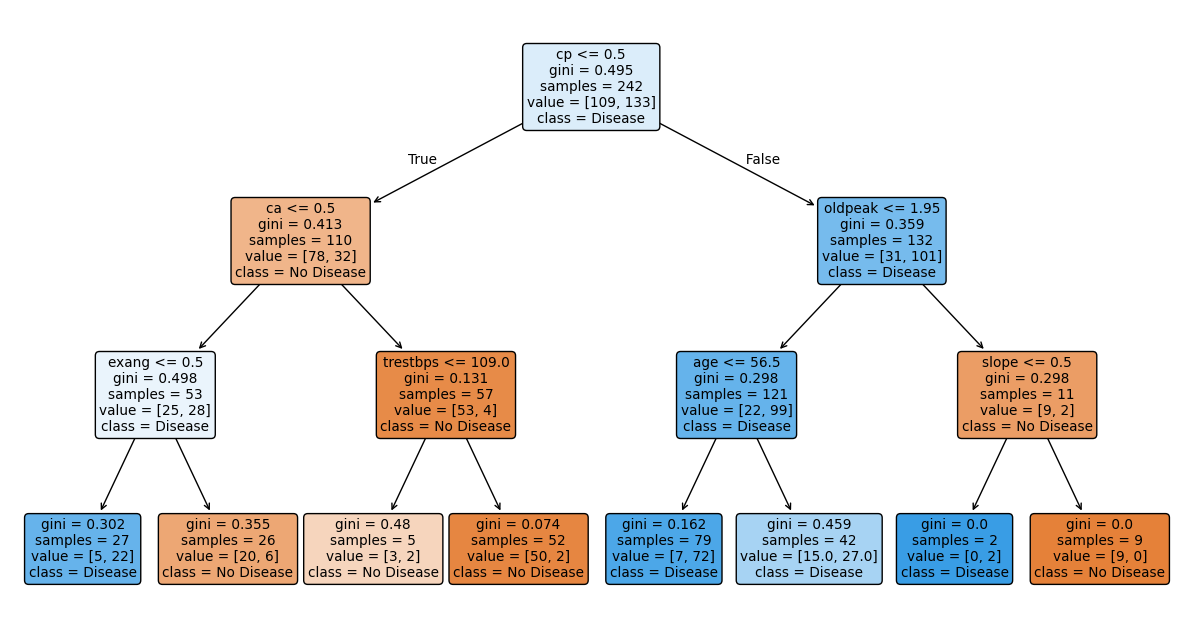

In [20]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree.fit(X_train, y_train)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
plot_tree(
    dtree,
    filled=True,
    feature_names=X_train.columns,
    class_names=["No Disease", "Disease"],
    rounded=True
)
plt.show()



*✏️ Your feature importance analysis here:*


### Q14 — predict vs predict_proba (6 pts)

Using the decision tree from Q13:

**Tasks:**
1. Create a DataFrame with the following columns for the **first 10 test samples** (3 pts):
   - `Actual` — true labels from `y_test`
   - `Predicted` — model predictions
   - `Prob_No_Disease` — probability of class 0
   - `Prob_Disease` — probability of class 1
2. Display the DataFrame (1 pt)
3. Find the sample where the model is **least confident** (probability closest to 0.5). Print its index and probabilities. (1 pt)
4. In markdown: what does it mean when `predict_proba` gives [0.5, 0.5]? How does the decision tree produce these probabilities? (1 pt)

In [13]:

import pandas as pd
import numpy as np

y_pred = social_model.predict(social_X_test)
y_prob = social_model.predict_proba(social_X_test)  

df_test_summary = pd.DataFrame({
    "Actual": social_y_test.iloc[:10].values,
    "Predicted": y_pred[:10],
    "Prob_No_Disease": y_prob[:10, 0],
    "Prob_Disease": y_prob[:10, 1]
})

print(df_test_summary)

confidence_diff = np.abs(y_prob[:, 1] - 0.5)
least_confident_idx = np.argmin(confidence_diff)

print("\nLeast confident sample index:", least_confident_idx)
print("Probabilities:", y_prob[least_confident_idx])


   Actual  Predicted  Prob_No_Disease  Prob_Disease
0       0          0         0.735366      0.264634
1       1          1         0.024993      0.975007
2       0          0         0.977386      0.022614
3       1          1         0.140998      0.859002
4       0          0         0.983726      0.016274
5       0          0         0.941932      0.058068
6       1          1         0.121594      0.878406
7       0          0         0.907688      0.092312
8       0          0         0.605612      0.394388
9       0          0         0.592295      0.407705

Least confident sample index: 48
Probabilities: [0.50225636 0.49774364]


When predict_proba gives [0.5, 0.5], the model is completely unsure about the prediction. In a decision tree, this happens when the sample falls into a leaf where the training data is evenly split between the two classes.


### Q15 — Ensemble Showdown: DT vs RF vs GB (7 pts)

Using the `X_train, X_test, y_train, y_test` from **Q4** (heart dataset):

**Tasks:**
1. Train all three models (3 pts):
   - `DecisionTreeClassifier(random_state=42)`
   - `RandomForestClassifier(n_estimators=20, random_state=42)`
   - `GradientBoostingClassifier(n_estimators=20, random_state=42)`
2. Print the **test accuracy** for each model using `accuracy_score` (1 pt)
3. Create a **bar plot** comparing the three accuracies (1 pt)
4. In markdown, answer BOTH: (2 pts)
   - What is **bagging** and how does Random Forest use it?
   - What is the key difference between **bagging** (Random Forest) and **boosting** (Gradient Boosting)?

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=20, random_state=42)
gb = GradientBoostingClassifier(n_estimators=20, random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)
gb_acc = accuracy_score(y_test, gb_pred)

print("Decision Tree Test Accuracy:", dt_acc)
print("Random Forest Test Accuracy:", rf_acc)
print("Gradient Boosting Test Accuracy:", gb_acc)


Decision Tree Test Accuracy: 0.7540983606557377
Random Forest Test Accuracy: 0.8360655737704918
Gradient Boosting Test Accuracy: 0.8360655737704918


*✏️ Your bagging vs boosting explanation here:*


### Q16 — Overfitting Experiment (6 pts)

Using the `X_train, X_test, y_train, y_test` from **Q4** (heart dataset):

**Tasks:**
1. Train a `RandomForestClassifier(n_estimators=20, random_state=42)` with each `max_depth` in: `[2, 3, 5, 10, None]` (2 pts)
2. For each, record the **train accuracy** and **test accuracy** (1 pt)
3. Plot both curves on the same graph (x-axis = max_depth, y-axis = accuracy). Use labels and a legend. Replace `None` with a label like `"None"` on the x-axis. (2 pts)
4. In markdown: at which `max_depth` does overfitting start? How can you tell? (1 pt)

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

depths = [2, 3, 5, 10, None]

train_accuracies = []
test_accuracies = []

for depth in depths:
    rf = RandomForestClassifier(
        n_estimators=20,
        max_depth=depth,
        random_state=42
    )
    
    rf.fit(X_train, y_train)
    
    train_pred = rf.predict(X_train)
    test_pred = rf.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"max_depth={depth} | Train Acc={train_acc:.3f} | Test Acc={test_acc:.3f}")


max_depth=2 | Train Acc=0.880 | Test Acc=0.885
max_depth=3 | Train Acc=0.876 | Test Acc=0.885
max_depth=5 | Train Acc=0.930 | Test Acc=0.885
max_depth=10 | Train Acc=0.992 | Test Acc=0.836
max_depth=None | Train Acc=0.996 | Test Acc=0.836


*✏️ Your overfitting analysis here:*


---
## Section 5: Model Pipeline & Deployment (10 pts)
*Estimated time: ~8 minutes*

---

### Q17 — Model Serialization with joblib (3 pts)

**Tasks:**
1. Take the **best-performing model** from Q15 (whichever had the highest test accuracy) (1 pt)
2. Save it to `"data/quiz_best_model.pkl"` using `joblib.dump()` (1 pt)
3. Load it back with `joblib.load()`, run predictions on `X_test`, and verify they match the original predictions using `np.array_equal()`. Print the result. (1 pt)

In [ ]:
import joblib
import numpy as np

best_model = best_rf_model 

joblib.dump(best_model, "data/quiz_best_model.pkl")

loaded_model = joblib.load("data/quiz_best_model.pkl")

original_preds = best_model.predict(X_test)
loaded_preds = loaded_model.predict(X_test)

match = np.array_equal(original_preds, loaded_preds)

print("Do predictions match after loading?", match)


### Q18 — FastAPI Design (4 pts)

You want to deploy your heart disease model as a REST API using **FastAPI**.

**Tasks — answer in the markdown cell below (pseudocode/code is fine, it doesn't need to run):**

1. Write a **Pydantic `BaseModel`** class called `HeartFeatures` with all 13 feature fields from `heart.csv`, using appropriate types (`int` or `float`). (1 pt)
2. Write a `POST /predict` endpoint that: accepts `HeartFeatures`, converts it to a DataFrame, runs the model prediction, and returns `{"prediction": 0 or 1, "probability": float}`. (1 pt)
3. What **logging** would you add to this endpoint? List at least 3 log messages with their appropriate levels (DEBUG, INFO, WARNING, ERROR, CRITICAL). (1 pt)
4. What **error handling** would you add? Describe at least 2 scenarios that could go wrong and how you'd handle them. (1 pt)

*✏️ Your FastAPI design here:*


### Q19 — Load Testing Design (3 pts)

You've deployed your heart disease API and need to verify it can handle traffic.

**Tasks — answer in the markdown cell below:**

1. What Python library/class would you use to send **500 concurrent requests**? (1 pt)
2. Write a function signature `run_load_test(num_requests: int)` and describe in pseudocode what it does (generate random data, send requests, collect results). (1 pt)
3. What **3 metrics** would you collect and report at the end of the load test? (1 pt)

*✏️ Your load testing design here:*


---
## Section 6: Boss Level — End-to-End Challenge (10 pts)
*Estimated time: ~8 minutes*

---

### Q20 — Full ML Pipeline (10 pts)

Using `social_df`, build a **complete ML pipeline** from scratch:

1. **Feature Engineering (2 pts):** Create at least **one new feature** (e.g., `Age_Salary_Ratio = Age / EstimatedSalary`, or binning Age into groups, or any creative transformation). Use both `Age` and `EstimatedSalary` plus your new feature(s) as inputs.

2. **Model Training (2 pts):** Train a `GradientBoostingClassifier` on your features.

3. **Threshold Optimization (2 pts):** Using `predict_proba`, find the threshold that maximizes the **F1 score** (hint: F1 = 2 * precision * recall / (precision + recall)). Print the optimal threshold and the F1 at that threshold.

4. **Final Evaluation (2 pts):** Apply your optimal threshold to the test set predictions. Print the `classification_report` at your chosen threshold.

5. **Save & Report (2 pts):**
   - Save the model to `"data/quiz_boss_model.pkl"` using joblib
   - In a markdown cell below, write a **3-sentence model report** explaining: what features you used, what threshold you chose and why, and how the model performed.

In [ ]:
# Q20 — Your code here

*✏️ Your 3-sentence model report here:*


---

## You're Done!

**Before submitting:**
1. **Restart the kernel** and **Run All Cells** — make sure everything runs without errors
2. Check that all markdown answers are filled in (search for `✏️`)
3. Save the notebook

**Good work!** 🎉